# Classification Model

## Set Up

In [1]:
import os
import sys

current_dir = os.getcwd()
new_root = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm'
sys.path.insert(0, new_root)

In [2]:
import configuration
import pandas as pd
import openpyxl
import random
import numpy as np

from src.data.load_data import * #load_configuration_parameters, load_file
from src.data.preprocess import *
from src.base.localizator import * #get_candidates
from src.features.build_features import *
from src.features.build_features_utils import *

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold, StratifiedShuffleSplit, GroupKFold
from sklearn import svm
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_validate
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.metrics import make_scorer, recall_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

## Read data


In [3]:
def set_sleep_stages_per_sample(signal, path_scoring: str, epoch_duration: int =30, sfreq: int =250):
    """
    Set sleep stages per sample in data
    """
    stages = np.loadtxt(path_scoring, skiprows=1)
    assert len(stages) == len(signal)//(epoch_duration*sfreq), "File with sleep stages annotations has a different amount of annotations comparing to the recording length"
    
    stages_per_sample = np.repeat(stages, epoch_duration*sfreq, axis=0) 

    return stages_per_sample

def get_candidates(signal:np.ndarray, path_scoring:str , sfreq: int, window_length: int = 2, stages_allowed:list =[2.0], step:float = 0.1) :
    """
    Detect KC candidates
    """
    stages_per_sample = set_sleep_stages_per_sample(signal, path_scoring, epoch_duration=30, sfreq=sfreq)    
    signal = signal[:len(stages_per_sample)]
    pos_candidate = []
    pos = 0
    while pos < len(signal):
        if stages_per_sample[pos] in stages_allowed:
            # print('Ok stage')
            window = signal[pos:pos+int(window_length*sfreq)]
            if check_if_meet_main_conditions(window, sfreq):
                # print('Ok meet main conditions')
                try:
                    window, idx_start, _, _, _, idx_end, new_pos = detect_points_of_event(window, sfreq, signal, pos, window_length=3)
                except AssertionError: # Could not find the points of the event correctly
                    # print('Could not find the points of the event correctly')
                    # print('Prev pos', pos)
                    pos += int(window_length/2*sfreq)
                    # print('Now pos', pos)
                    continue
                # print('FOUND CANDIDATE')
                if len(pos_candidate) >= 1:
                    if (new_pos + idx_start) <= (pos_candidate[-1][0]+pos_candidate[-1][1])*sfreq:
                        # print('Changed new_pos')
                        new_pos = int((pos_candidate[-1][0]+pos_candidate[-1][1])*sfreq + 1)

                if new_pos + idx_end < len(signal):
                    pos_candidate.append([(new_pos + idx_start)/sfreq, (idx_end-idx_start)/sfreq]) #[onset, duration]
                # print('KC from', new_pos + idx_start, 'to', new_pos + idx_end)
                # print('Prev pos', pos)
                pos = new_pos + idx_end + 1
                # print('Now pos', pos)
            else:
                # print('Do not meet main conditions')
                # print('Prev pos', pos)
                pos += int(step*sfreq)
                # print('Now pos', pos)
        else:
            # print('Wrong stage')
            # print('Prev pos', pos)
            pos += int(30*sfreq)
            # print('Now pos', pos)
    
    predicted = []
    for p in pos_candidate:
        predicted.append([p[0],p[1]])
        
    return predicted

def load_expert_annotations(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]  # Skip header line
    annotations = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 2:
            continue
        start, duration = map(float, parts[:2])
        end = start + duration
        annotations.append((start, end))
    return annotations

def load_stage2_epochs(hypnogram_path):
    with open(hypnogram_path, 'r') as f:
        stages = [line.strip() for line in f.readlines()]
    return stages

def filter_annotations_by_stage2(filepath, stage2_epochs):
    annotations = []
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]  # Skip header
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            start, duration = map(float, parts[:2])
            end = start + duration
            midpoint = (start + end) / 2
            epoch_idx = int(midpoint // 30)
            if epoch_idx < len(stage2_epochs) and stage2_epochs[epoch_idx] == "2":
                annotations.append((start, end))
    return annotations

def is_candidate_overlapping(candidate, annotations):
    c_start, c_dur = candidate
    c_end = c_start + c_dur
    for a_start, a_end in annotations:
        if a_start <= c_end and a_end >= c_start:
            return True
    return False

def label_candidates_and_count_matches(candidates, expert1_path, expert2_path="", hypnogram_path="", subject_num=1):
    stage2_epochs = load_stage2_epochs(hypnogram_path)

    expert1_annotations = filter_annotations_by_stage2(expert1_path, stage2_epochs)
    if subject_num <= 5:
        expert2_annotations = filter_annotations_by_stage2(expert2_path, stage2_epochs)

    labels = []
    matched_expert1 = set()
    if subject_num <= 5:
        matched_expert2 = set()

    for i, candidate in enumerate(candidates):
        in_exp1 = is_candidate_overlapping(candidate, expert1_annotations)
        in_exp2 = False
        if subject_num <= 5:
            in_exp2 = is_candidate_overlapping(candidate, expert2_annotations)

        if in_exp1 and in_exp2:
            labels.append("both")
        elif in_exp1:
            labels.append("expert1")
        elif in_exp2:
            labels.append("expert2")
        else:
            labels.append("none")

        # Track which expert annotations were matched by any candidate
        for idx, (a_start, a_end) in enumerate(expert1_annotations):
            if a_start <= candidate[0] + candidate[1] and a_end >= candidate[0]:
                matched_expert1.add(idx)
        if subject_num <=5:
            for idx, (a_start, a_end) in enumerate(expert2_annotations):
                if a_start <= candidate[0] + candidate[1] and a_end >= candidate[0]:
                    matched_expert2.add(idx)

    # Final counts
    total_exp1 = len(expert1_annotations)
    num_matched_exp1 = len(matched_expert1)
    if subject_num <=5:
        total_exp2 = len(expert2_annotations)
        num_matched_exp2 = len(matched_expert2)
    
        return labels, {
            "expert1_total": total_exp1,
            "expert1_matched": num_matched_exp1,
            "expert2_total": total_exp2,
            "expert2_matched": num_matched_exp2
        }, expert1_annotations, expert2_annotations
    
    else:
        return labels, {
            "expert1_total": total_exp1,
            "expert1_matched": num_matched_exp1}, expert1_annotations, []
    
def get_KC_event(onset_duration, signal, sfreq, window=2, timelocked2='center', return_start_of_event=False):
    """
    Get KC event
    """
    onset, duration = onset_duration
    if timelocked2 == 'center':
        start = int(onset*sfreq)
        end = int(start + duration*sfreq)
        KC_labeled = signal[start:end]
        center, maxi, mini = get_center_maxi_mini(KC_labeled)
        center_in_signal = int(start + center)
        mini_to_center = abs(mini-center)
        maxi_to_center = abs(maxi-center)
        new_start = center_in_signal-int(window*sfreq/2)
        KC = signal[new_start:center_in_signal+int(window*sfreq/2)]
    elif timelocked2 == 'min':
        start = int(onset*sfreq)
        end = int(start + duration*sfreq)
        KC_labeled = signal[start:end]
        center, maxi, mini = get_center_maxi_mini(KC_labeled)
        center_in_signal = start + mini
        mini_to_center = 0
        maxi_to_center = abs(maxi-mini)
        new_start = center_in_signal-int(window*sfreq/2)
        #KC = signal[new_start:center_in_signal-int(window*sfreq/2)]
        KC = signal[new_start:new_start+int(window*sfreq)]

    if return_start_of_event:
        return new_start
    else:
        return KC, maxi_to_center, mini_to_center
    
def is_there_any_candidates_overlapping(candidates):
    #[onset, duration]
    for cand1, cand2 in zip(candidates[:-1],candidates[1:]):
        onset1, duration1 = cand1[0], cand1[1]
        onset2, duration2 = cand2[0], cand2[1]
        if onset2 < onset1 + duration1:
            print(onset1, duration1)
            print(onset2, duration2)
            return True
    
    return False

In [4]:
def confusion_matrix_scorer(clf, X, y):
    y_pred = clf.predict(X)
    labels_order = ["KC", "noKC"]  # Explicit order
    cm = confusion_matrix(y, y_pred, labels=labels_order)
    return {'tn': cm[0, 0], 'fp': cm[0, 1],
            'fn': cm[1, 0], 'tp': cm[1, 1]}

In [ ]:
# timelocked2 = 'center'
# expert = 'any_both'
# window = 2
# fs = 200

# if expert == 'expert1':
#     list_of_experts = ['both', 'expert1']
#     subjects = [i+1 for i in range(10)]
# elif expert == 'expert2':
#     list_of_experts = ['both', 'expert2']
#     subjects = [i+1 for i in range(5)]
# elif expert == 'any_both':
#     list_of_experts = ['both', 'expert2', 'expert1']
#     subjects = [i+1 for i in range(5)]
# elif expert == 'both_same_time':
#     list_of_experts = ['both']
#     subjects = [i+1 for i in range(5)]

# df_overall = pd.DataFrame(data=[], columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject", "Label"])

# for subject_num in subjects:
#     print('Analyzing subject',subject_num, '...')

#     # Read annotation from experts
#     annot_file1 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring1_excerpt'+str(subject_num)+'.txt'
#     data = np.loadtxt(annot_file1, skiprows=1)
#     event_times1, durations1 = data[:, 0], data[:, 1]

#     if subject_num <= 5: #Specialist 2 only annotate from subj 1 to 5
#         annot_file2 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring2_excerpt'+str(subject_num)+'.txt'
#         data = np.loadtxt(annot_file2, skiprows=1)
#         event_times2, durations2 = data[:, 0], data[:, 1]
#     else:
#         event_times2, durations2 = np.array([]), np.array([]) 
    
#     # Read annotations from DREAMS automatic algorithm
#     dreams_detection_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Automatic_detection_excerpt'+str(subject_num)+'.txt'
#     data = np.loadtxt(dreams_detection_file, skiprows=1)
#     predicted_event_times, predicted_durations = data[:, 0], data[:, 1]

#     # Read sleep scoring file
#     scoring_file_30s = r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Hypnogram_excerpt"+str(subject_num)+"_30s_epoch.txt"
#     with open(scoring_file_30s, 'r') as f:
#         lines = f.readlines()[1:]  # skip first line
#         stages = np.array([int(line.strip()) for line in lines])
    
#     # Identify epochs with stage 2
#     stage_2_indices = np.where(stages == 2)[0]

#     # Assume each epoch is 30 seconds long
#     epoch_duration = 30  # seconds
#     time_stage_2 = stage_2_indices * epoch_duration

#     # Create binary indicator for plotting
#     indicator = np.zeros_like(stages, dtype=int)
#     indicator[stage_2_indices] = 1

#     # Read edf file
#     edf_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\excerpt'+ str(subject_num) +'.edf'
#     raw = mne.io.read_raw_edf(edf_file, preload=True)
#     channels = raw.info['ch_names']

#     # Filter only channel to use
#     raw_filtered = raw.copy().filter(l_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][0], h_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][1], picks='CZ-A1')

#     # Get channel to detect candidates and sample frequency
#     x = raw_filtered.get_data(picks='CZ-A1').flatten()
#     fs = raw.info['sfreq']

#     # LOCALIZATOR - Get candidates
#     candidates = get_candidates(signal=x, path_scoring=scoring_file_30s , sfreq=fs, window_length=2)

#     if is_there_any_candidates_overlapping(candidates):
#         print('CHECK OVERLAP!')

#     labels, match_stats, expert1_annotations, expert2_annotations = label_candidates_and_count_matches(candidates,
#                                                                                                         annot_file1,
#                                                                                                         annot_file2,
#                                                                                                         scoring_file_30s,
#                                                                                                         subject_num)

#     events = []
#     for cand, lab in zip(candidates, labels):
#         #print(cand)
#         cand_event = get_KC_event(cand, x, sfreq=fs, window=2, timelocked2=timelocked2)[0].tolist()
#         if lab in list_of_experts:
#             cand_lab = 'KC'
#         else:
#             cand_lab = 'noKC'
#         events.append(cand_event + [subject_num, cand_lab])
    
#     #List of events
#     df_events = pd.DataFrame(data=events, columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject","Label"])
#     df_overall = pd.concat([df_overall, df_events],  ignore_index=True)


# #Deleting NaN rows as they were candidates out of S2
# df_overall.drop(df_overall[df_overall['Label'].isna()].index, inplace=True)

# df_overall.head()
# df_overall = df_overall.dropna()

# df_overall['Flag'] = np.where(df_overall['Label'] == 'KC', 1, 0)
# subj_numKCs = df_overall[df_overall['Label'] == 'KC'].groupby('Subject').nunique()['sample1']

# for numKCs, subject_num in zip(subj_numKCs, subj_numKCs.index):
#     subject_num = int(subject_num)
#     idxs_to_flag = df_overall[(df_overall['Subject'] == subject_num) & (df_overall['Label'] == 'noKC')].sample(numKCs).index
#     df_overall.loc[idxs_to_flag, 'Flag'] = 1

# df_overall.to_csv(f'DREAMS_overall_timelocked2{timelocked2}_{expert}.csv')

In [ ]:
# df_overall['Flag'] = np.where(df_overall['Label'] == 'KC', 1, 0)
# subj_numKCs = df_overall[df_overall['Label'] == 'KC'].groupby('Subject').nunique()['sample1']

# for numKCs, subject_num in zip(subj_numKCs, subj_numKCs.index):
#     subject_num = int(subject_num)
#     idxs_to_flag = df_overall[(df_overall['Subject'] == subject_num) & (df_overall['Label'] == 'noKC')].sample(numKCs).index
#     df_overall.loc[idxs_to_flag, 'Flag'] = 1

# # df_overall.to_csv(f'DREAMS_overall_timelocked2{timelocked2}_{expert}.csv')

In [ ]:
# if expert == 'expert1':
# elif expert == 'expert2':
# elif expert == 'any_both':
# elif expert == 'both_same_time':

In [21]:
timelocked2 = 'center'
expert = 'expert1'
df_overall = pd.read_csv(rf'C:\Users\ayvazquez\aylin\KC_detection_algorithm\reports\models\DREAMS_overall_timelocked2{timelocked2}_{expert}.csv').drop(columns='Unnamed: 0')

In [22]:
df_overall['Label'].value_counts()

Label
noKC    5041
KC       235
Name: count, dtype: int64

In [23]:
df_model = df_overall[df_overall['Flag'] == 1].reset_index()
df_model = df_model.drop(columns='index')

In [24]:
y_overall = df_overall.copy()['Label']
X_overall = df_overall.drop(columns=['Label','Subject','Flag'])

scaler2 = MinMaxScaler()
scaler2.fit(X_overall.values.T)
X_overall_scaled2 = scaler2.transform(X_overall.values.T) #Scaled in rows
X_overall_scaled2 = pd.DataFrame(data=X_overall_scaled2.T, columns=X_overall.columns)

scaler2 = MinMaxScaler()
scaler2.fit(X_overall.values.T)
X_overall_scaled2 = scaler2.transform(X_overall.values.T) #Scaled in rows
X_overall_scaled2 = pd.DataFrame(data=X_overall_scaled2.T, columns=X_overall.columns)

In [25]:
y_model = df_model.copy()['Label']
X_model = df_model.drop(columns=['Label','Subject','Flag'])
scaler2 = MinMaxScaler()
scaler2.fit(X_model.values.T)
X_model_scaled2 = scaler2.transform(X_model.values.T) #Scaled in rows
X_model_scaled2 = pd.DataFrame(data=X_model_scaled2.T, columns=X_model.columns)

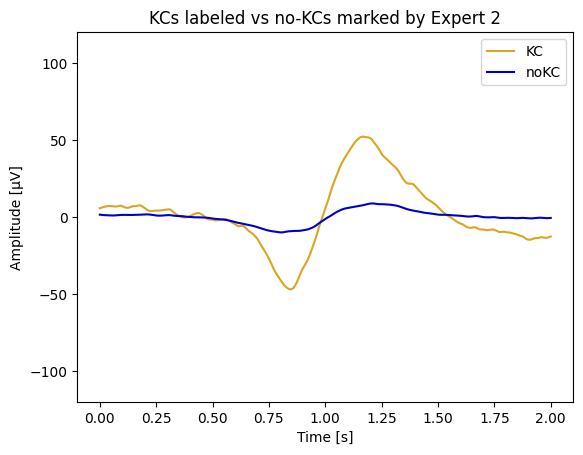

In [26]:
t = np.linspace(0,2,2*200)
plt.plot(t, np.mean(X_overall.iloc[np.where(y_overall == 'KC')], axis=0).values, label='KC', color = 'goldenrod')
plt.plot(t, np.mean(X_overall.iloc[np.where(y_overall == 'noKC')], axis=0).values, label='noKC', color = 'mediumblue')
plt.legend()
plt.title(f'KCs labeled vs no-KCs marked by Expert 2')
plt.ylim(-120,120)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [μV]')
plt.savefig(rf'KC_vs_noKC_{expert}_timelocked2{timelocked2}.png')

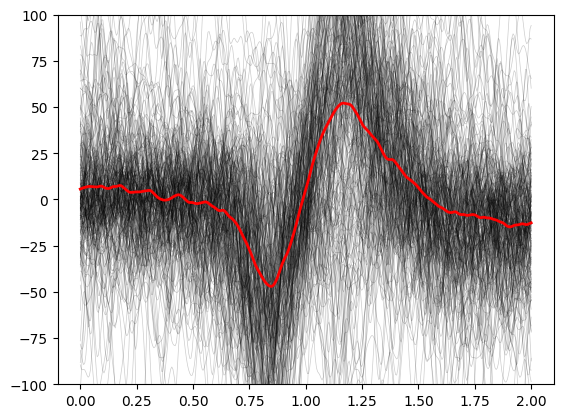

In [27]:
t = np.linspace(0,2,2*200)
signals = X_overall.iloc[np.where(y_overall == 'KC')]
for i in range(len(signals)):
    plt.plot(t, signals.iloc[i], alpha=0.2, color='black', linewidth=0.5)
plt.plot(t, np.mean(signals,axis=0), 'r', linewidth=2)
plt.ylim([-100,100])
plt.show()


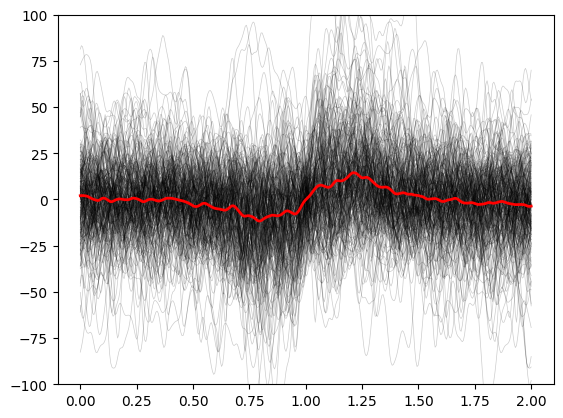

In [28]:
t = np.linspace(0,2,2*200)
signals = X_overall.iloc[np.where(y_overall == 'noKC')][:250]
for i in range(len(signals)):
    plt.plot(t, signals.iloc[i], alpha=0.2, color='black', linewidth=0.5)
plt.plot(t, np.mean(signals,axis=0), 'r', linewidth=2)
plt.ylim([-100,100])
plt.show()

In [ ]:
# df_overall.to_csv('overall_results_labeled_events_timelocked2min_DREAMSddbb.csv')
# df_overall.to_csv('overall_results_labeled_events_timelocked2center_DREAMSddbb.csv')

In [150]:
X_model_train, X_model_test, y_model_train, y_model_test = train_test_split(X_model, y_model, test_size=0.2, random_state=10)

X_overall_train, X_overall_test, y_overall_train, y_overall_test = train_test_split(X_overall, y_overall, test_size=0.2, random_state=10)

X_overall_scaled2_train, X_overall_scaled2_test, y_overall_scaled2_train, y_overall_scaled2_test = train_test_split(X_overall_scaled2, y_overall, test_size=0.2, random_state=10)


In [ ]:
# t = np.linspace(0,2,2*200)
# plt.plot(t, np.mean(X_overall_scaled.iloc[np.where(y_overall == 'KC')], axis=0).values, label=f"KC (N={len(X_overall_scaled.iloc[np.where(y_overall == 'KC')])})")
# plt.plot(t, np.mean(X_overall_scaled.iloc[np.where(y_overall == 'noKC')], axis=0).values, label=f"noKC (N={len(X_overall_scaled.iloc[np.where(y_overall == 'noKC')])})")
# plt.legend()
# plt.title('Mean of KC vs mean noKC - Scaled samples')
# plt.show()

In [ ]:
# t = np.linspace(0,2,2*200)
# plt.plot(t, np.mean(X_model_scaled.iloc[np.where(y_model == 'KC')], axis=0).values, label=f'KC (N={len(X_model_scaled.iloc[np.where(y_model == "KC")])})')
# plt.plot(t, np.mean(X_model_scaled.iloc[np.where(y_model == 'noKC')], axis=0).values, label=f'noKC (N={len(X_model_scaled.iloc[np.where(y_model == "noKC")])})')
# plt.legend()
# plt.title('Mean of KC vs mean noKC - Balanced and scaled samples')
# plt.show()

In [ ]:
# t = np.linspace(0,2,2*200)
# plt.plot(t, np.mean(X_model.iloc[np.where(y_model == 'KC')], axis=0).values, label=f'KC (N={len(X_model.iloc[np.where(y_model == "KC")])})')
# plt.plot(t, np.mean(X_model.iloc[np.where(y_model == 'noKC')], axis=0).values, label=f'noKC (N={len(X_model.iloc[np.where(y_model == "noKC")])})')
# plt.legend()
# plt.title(f'Mean of KC vs mean noKC - Balanced samples (N={len(X_overall)}')
# plt.show()

In [ ]:
# t = np.linspace(0,2,2*200)
# plt.plot(t, np.mean(X_overall.iloc[np.where(y_overall == 'KC')], axis=0).values, label=f'KC {len(X_overall.iloc[np.where(y_overall == "KC")])}')
# plt.plot(t, np.mean(X_overall.iloc[np.where(y_overall == 'noKC')], axis=0).values, label=f'noKC {len(X_overall.iloc[np.where(y_overall == "noKC")])}')
# plt.legend()
# plt.title(f'Mean of KC vs mean noKC - All samples (N={len(X_overall)})')
# plt.show()

In [13]:
def confusion_matrix_scorer(clf, X, y):
    y_pred = clf.predict(X)
    labels_order = ["KC", "noKC"]  # Explicit order
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=labels_order).ravel()
    return {'tn': tn, 'fp': fp,
            'fn': fn, 'tp': tp}

In [15]:
best_model_lsym = BalancedBaggingClassifier(estimator=svm.NuSVC(gamma=0.054082165807184904,
                                          kernel='poly',
                                          nu=0.04042125351469507),
                          n_estimators=15, n_jobs=-1, random_state=42)

## Models

### SVC

In [ ]:
def run_SVC(X, y):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

    #KERNEL
    scores = []
    kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
    for k in kernels:
        score = svm.SVC(kernel=k).fit(X_test, y_test).score(X_test, y_test)
        scores.append(score)
    plt.plot(kernels, scores)
    plt.title('SVM type of kernel comparison')
    plt.ylabel('Accuracy')
    plt.show()
    kernel_selected = kernels[scores.index(max(scores))]
    print(f'Kernel selected: "{kernel_selected}"')

    #C
    scores = []
    Cs = np.linspace(0.1,0.9,9*10)
    for c in Cs:
        score = svm.SVC(C=c, kernel=kernel_selected).fit(X_train, y_train).score(X_test, y_test)
        scores.append(score)

    plt.plot(Cs, scores)
    plt.title('SVM C parameter comparison')
    plt.ylabel('Accuracy')
    plt.xlabel('C')
    plt.show()
    C_selected = Cs[scores.index(max(scores))]
    print(f'C selected: "{C_selected}"')

    #Gamma
    scores = []
    gammas = ['scale', 'auto']
    for g in gammas:
        score = svm.SVC(C=C_selected, kernel=kernel_selected, gamma=g).fit(X_train, y_train).score(X_test, y_test)
        scores.append(score)
    plt.plot(gammas, scores)
    plt.title('SVM gamma parameter comparison')
    plt.ylabel('Accuracy')
    plt.xlabel('gamma')
    plt.show()
    gamma_selected = gammas[scores.index(max(scores))]
    print(f'Gamma selected: "{gamma_selected}"')

    #Check performance of method
    print('PERFORMANCE:')
    print('Crossvalidation x10')

    clf = svm.SVC(C=C_selected, kernel=kernel_selected, gamma=gamma_selected)
    for sc in ('accuracy','f1_macro','recall_macro'):
        scores = cross_val_score(clf, X, y, cv=10, scoring=sc)
        print(sc, round(scores.mean(),2), '+-', round(scores.std(),2))
    
    cv_results = cross_validate(clf, X, y, cv=10,
                            scoring=confusion_matrix_scorer)

    TP = round(float(np.mean(cv_results['test_tp'])),2)
    FP = round(float(np.mean(cv_results['test_fp'])),2)
    FN = round(float(np.mean(cv_results['test_fn'])),2)
    TN = round(float(np.mean(cv_results['test_tn'])),2)

    cm_num = np.array([[TP, FN],[FP, TN]])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()

    t = np.linspace(0,2,2*200)
    plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
    plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
    plt.legend()
    plt.title('KC predicted vs KC true')
    plt.show()

    t = np.linspace(0,2,2*200)
    plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
    plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
    plt.legend()
    plt.title('noKC predicted vs noKC true')
    plt.show()

    print(f"svm.SVC(C={C_selected}, kernel={kernel_selected}, gamma={gamma_selected})")

In [ ]:
# run_SVC(X=X_model, y=y_model)

In [ ]:
# run_SVC(X=X_model_scaled, y=y_model)

In [ ]:
# run_SVC(X=X_model_scaled2, y=y_model)

In [ ]:
# run_SVC(X=X_overall, y=y_overall)

In [ ]:
# run_SVC(X=X_overall_scaled, y=y_overall)

### Balanced Bagging Classifier


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_overall_scaled2, y_overall, test_size=0.2, random_state=10)

# Define your combined scorer
def combined_score(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    recall_kc = recall_score(y_true, y_pred, pos_label='KC')
    return acc + 0.3 * recall_kc

combined_scorer = make_scorer(combined_score, greater_is_better=True)

# Calculate max nu
l = len(y_overall)
l_pos = len(np.where(y_overall == 'KC')[0])
l_neg = len(np.where(y_overall == 'noKC')[0])
max_nu = min(l_pos/l, l_neg/l)

# Define the model
bbc = BalancedBaggingClassifier(
    estimator=svm.NuSVC(),
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

# Define parameter grid
param_grid = {
    "estimator__nu": loguniform(1e-4, max_nu * 2),
    "estimator__gamma": loguniform(1e-4, 1),
    "estimator__kernel": ['poly', 'rbf', 'sigmoid'],
    "n_estimators": [5, 10, 15]
}

# Randomized search
clf = RandomizedSearchCV(
    estimator=bbc,
    param_distributions=param_grid,
    n_iter=15,
    scoring=combined_scorer,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=5,
                   estimator=BalancedBaggingClassifier(estimator=NuSVC(),
                                                       n_jobs=-1,
                                                       random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'estimator__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001F1431A1BE0>,
                                        'estimator__kernel': ['poly', 'rbf',
                                                              'sigmoid'],
                                        'estimator__nu': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001F14331E670>,
                                        'n_estimators': [5, 10, 15]},
                   random_state=42,
                   scoring=make_scorer(combined_score, response_method='predict'),
                   verbose=2)

In [17]:
best_model = clf.best_estimator_
best_model

BalancedBaggingClassifier(estimator=NuSVC(gamma=np.float64(0.43379206974909373),
                                          nu=np.float64(0.00900126699301227)),
                          n_jobs=-1, random_state=42)

In [18]:
best_model_lsym

BalancedBaggingClassifier(estimator=NuSVC(gamma=0.054082165807184904,
                                          kernel='poly',
                                          nu=0.04042125351469507),
                          n_estimators=15, n_jobs=-1, random_state=42)

In [ ]:
# probability = best_model.predict_proba(X_overall_scaled2)
# y_pred = best_model.predict(X_overall_scaled2)

# KC_prob = probability[:,0]
# noKC_prob = probability[:,1]

In [ ]:
# probability = best_model.predict_proba(X_overall_scaled2)
# y_pred = best_model.predict(X_overall_scaled2)

# KC_prob = probability[:,0]
# noKC_prob = probability[:,1]

# y_false_positive = X_overall_scaled2.iloc[np.where((KC_prob > 0.7) & (y_overall == 'noKC'))]
# y_false_negative = X_overall_scaled2.iloc[np.where((noKC_prob > 0.5) & (y_overall == 'KC'))]

# plt.figure(figsize=(10,5))
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_pred == 'KC')].mean(axis=0), 
#          color='blue', 
#          linewidth = 2,
#          label='Predicted KC')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), '--c', label='True KC')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_pred == 'noKC')].mean(axis=0), 
#          color='orange', 
#          linewidth = 2,
#          label='Predicted noKC')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'noKC')].mean(axis=0), '--r', label='True noKC')
# #plt.plot(t, X_overall_train.mean(axis=0), '--k', label='Average')
# plt.plot(t, y_false_positive.mean(axis=0), label = f'False Positives (N={len(y_false_positive)})', color = 'limegreen')
# # plt.plot(t, y_false_negative.mean(axis=0), label = f'False Negative (N={len(y_false_negative)})', color = 'maroon')
# plt.legend()
# plt.show()

# plt.figure(figsize=(10,5))
# for i in range(len(y_false_positive)):
#     sig = y_false_positive.iloc[i]
#     plt.plot(t,sig, alpha=0.25, linewidth=0.25, color='black')

# plt.plot(t, y_false_positive.mean(axis=0), label = 'False Positives', color = 'limegreen')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), 'c', label='True KC')
# plt.legend()
# plt.show()

# # for i in range(len(y_false_negative)):
# #     plt.figure(figsize=(10,5))
# #     sig = y_false_negative.iloc[i]
# #     plt.plot(t,sig, alpha=0.75, linewidth=0.5, color='black')
# #     plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), 'c', label='True KC')
# #     plt.legend()
# #     plt.show()
    

# # plt.plot(t, y_false_negative.mean(axis=0), label = 'False Negative', color = 'limegreen')
# # plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), 'c', label='True KC')
# # plt.legend()
# # plt.show()

In [ ]:
# best_model_lsym_dbbb = BalancedBaggingClassifier(estimator=svm.NuSVC(gamma=0.054082165807184904,
#                                                                 kernel='poly',
#                                                                 nu=0.04042125351469507),
#                                                             n_estimators=15, n_jobs=-1, random_state=42)

# best_model_lsym_dbbb.fit(X_train, y_train)

# probability = best_model_lsym_dbbb.predict_proba(X_overall_scaled2)
# y_pred = best_model_lsym_dbbb.predict(X_overall_scaled2)

# KC_prob = probability[:,0]
# noKC_prob = probability[:,1]

# y_false_positive = X_overall_scaled2.iloc[np.where((KC_prob > 0.7) & (y_overall == 'noKC'))]
# y_false_negative = X_overall_scaled2.iloc[np.where((noKC_prob > 0.5) & (y_overall == 'KC'))]

# plt.figure(figsize=(10,5))
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_pred == 'KC')].mean(axis=0), 
#          color='blue', 
#          linewidth = 2,
#          label='Predicted KC')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), '--c', label='True KC')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_pred == 'noKC')].mean(axis=0), 
#          color='orange', 
#          linewidth = 2,
#          label='Predicted noKC')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'noKC')].mean(axis=0), '--r', label='True noKC')
# #plt.plot(t, X_overall_train.mean(axis=0), '--k', label='Average')
# plt.plot(t, y_false_positive.mean(axis=0), label = f'False Positives (N={len(y_false_positive)})', color = 'limegreen')
# # plt.plot(t, y_false_negative.mean(axis=0), label = f'False Negative (N={len(y_false_negative)})', color = 'maroon')
# plt.legend()
# plt.show()

# plt.figure(figsize=(10,5))
# for i in range(len(y_false_positive)):
#     sig = y_false_positive.iloc[i]
#     plt.plot(t,sig, alpha=0.25, linewidth=0.25, color='black')

# plt.plot(t, y_false_positive.mean(axis=0), label = 'False Positives', color = 'limegreen')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), 'c', label='True KC')
# plt.legend()
# plt.show()

# # for i in range(len(y_false_negative)):
# #     plt.figure(figsize=(10,5))
# #     sig = y_false_negative.iloc[i]
# #     plt.plot(t,sig, alpha=0.75, linewidth=0.5, color='black')
# #     plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), 'c', label='True KC')
# #     plt.legend()
# #     plt.show()
    

# # plt.plot(t, y_false_negative.mean(axis=0), label = 'False Negative', color = 'limegreen')
# # plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), 'c', label='True KC')
# # plt.legend()
# # plt.show()

In [ ]:
# def run_BalancedBaggingClassifier(X, y, mode):
#         X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
#         scores = []        
#         if mode == 'NuSVM':    
#                 l = len(y) #number of training samples
#                 l_pos = len(np.where(y == 'KC')[0]) #number of KC
#                 l_neg = len(np.where(y == 'noKC')[0]) #number of noKC
#                 max_nu = min(l_pos/l,l_neg/l)
#                 #Kernel
#                 kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
#                 for k in kernels:
#                         clf = svm.NuSVC(kernel=k, nu=max_nu*2).fit(X_train, y_train)
#                         # clf = BalancedBaggingClassifier(base_classifier,
#                         #                                     n_estimators = 5,
#                         #                                     sampling_strategy='auto',  
#                         #                                     replacement=False,  # Whether to sample with or without replacement
#                         #                                     random_state=42).fit(X_train, y_train)
#                         y_pred = clf.predict(X_test)
#                         score = recall_score(y_test, y_pred, pos_label='KC')
#                         scores.append(score)
#                 kernel_selected = kernels[scores.index(max(scores))]
#                 print(f'Kernel selected: "{kernel_selected}"')
#                 #Nu
#                 scores = []
#                 Nus = np.linspace(0.001,max_nu*2,9*10)
#                 for nu in Nus:
#                         clf = svm.NuSVC(nu=nu, kernel='rbf', gamma=0.002).fit(X_train, y_train)
#                         # clf = BalancedBaggingClassifier(base_classifier,
#                         #                                     n_estimators = 5,
#                         #                                     sampling_strategy='auto',  
#                         #                                     replacement=False,  # Whether to sample with or without replacement
#                         #                                     random_state=42).fit(X_train, y_train)
#                         y_pred = clf.predict(X_test)
#                         score = recall_score(y_test, y_pred, pos_label='KC')
#                         scores.append(score)
#                 nu_selected = Nus[scores.index(max(scores))]
#                 print(f'Nu selected: "{nu_selected}"')
#                 #Gamma
#                 scores = []
#                 gammas = np.linspace(1/500, 3, 10)
#                 for g in gammas:
#                         clf = svm.NuSVC(nu=nu, kernel=kernel_selected, gamma=g).fit(X_train, y_train)
#                         # clf = BalancedBaggingClassifier(base_classifier,
#                         #                                     n_estimators = 5,
#                         #                                     sampling_strategy='auto',  
#                         #                                     replacement=False,  # Whether to sample with or without replacement
#                         #                                     random_state=42).fit(X_train, y_train)
#                         y_pred = clf.predict(X_test)
#                         score = recall_score(y_test, y_pred, pos_label='KC')
#                         scores.append(score)
#                 gamma_selected = gammas[scores.index(max(scores))]
#                 print(f'Gamma selected: "{gamma_selected}"')
#                 base_classifier = svm.NuSVC(nu=nu_selected, kernel=kernel_selected, gamma=gamma_selected)
#                 print(f"Nu-SVM Model selected: svm.NuSVC(nu={nu_selected}, kernel='{kernel_selected}', gamma='{gamma_selected}')")

#         elif mode == 'SVM':
#                 #Kernel
#                 kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
#                 for k in kernels:
#                         score = svm.SVC(kernel=k).fit(X_train, y_train).recall_score(X_test, y_test)
#                         scores.append(score)
#                 kernel_selected = kernels[scores.index(max(scores))]
#                 print(f'Kernel selected: "{kernel_selected}"')
#                 #C
#                 scores = []
#                 Cs = np.linspace(0.1,0.9,9*10)
#                 for c in Cs:
#                         score = svm.SVC(C=c, kernel=kernel_selected).fit(X_train, y_train).score(X_test, y_test)
#                         scores.append(score)
#                 C_selected = Cs[scores.index(max(scores))]
#                 print(f'C selected: "{C_selected}"')

#                 #Gamma
#                 scores = []
#                 gammas = ['scale', 'auto']
#                 for g in gammas:
#                         score = svm.SVC(C=C_selected, kernel=kernel_selected, gamma=g).fit(X_train, y_train).score(X_test, y_test)
#                         scores.append(score)
#                 gamma_selected = gammas[scores.index(max(scores))]
#                 print(f'Gamma selected: "{gamma_selected}"')
#                 base_classifier = svm.SVC(C=C_selected, kernel=kernel_selected, gamma=gamma_selected)
#                 print(f"SVM Model selected: svm.SVC(C={C_selected}, kernel='{kernel_selected}', gamma='{gamma_selected}')")

    
#         balanced_bagging_classifier = BalancedBaggingClassifier(base_classifier,
#                                                             n_estimators = 5,
#                                                             sampling_strategy='auto',  
#                                                             replacement=False,  # Whether to sample with or without replacement
#                                                             random_state=42)

#         for sc in ('accuracy','f1_macro','recall_macro'):
#                 scores = cross_val_score(balanced_bagging_classifier, X, y, cv=10, scoring=sc)#, fit_params={'sample_weight': sample_weight})
#                 print(sc, round(scores.mean(),2), '+-', round(scores.std(),2))
                
#         cv_results = cross_validate(balanced_bagging_classifier, X, y, cv=10,
#                                 scoring=confusion_matrix_scorer)

#         TP = round(float(np.mean(cv_results['test_tp'])),2)
#         FP = round(float(np.mean(cv_results['test_fp'])),2)
#         FN = round(float(np.mean(cv_results['test_fn'])),2)
#         TN = round(float(np.mean(cv_results['test_tn'])),2)

#         cm_num = np.array([[TN, FP],[FN, TP]])

#         # Fit the model
#         X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
#         balanced_bagging_classifier.fit(X_train, y_train)

#         # Make predictions
#         y_pred = balanced_bagging_classifier.predict(X_test)

#         cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
#         cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

#         ConfusionMatrixDisplay(cm_num, display_labels=['noKC','KC'] ).plot(cmap='Blues', colorbar=False, values_format='.1f')
#         plt.title('Average number of predicted')
#         plt.show()
#         ConfusionMatrixDisplay(cm_normalized_true, display_labels=['noKC','KC'] ).plot(cmap='Blues', colorbar=False)
#         plt.title('Normalized by true labels')
#         plt.show()
#         ConfusionMatrixDisplay(cm_normalized_pred, display_labels=['noKC','KC'] ).plot(cmap='Blues', colorbar=False)
#         plt.title('Normalized by predicted labels')
#         plt.show()

#         t = np.linspace(0,2,2*200)
#         plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
#         plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
#         plt.legend()
#         plt.title('KC predicted vs KC true')
#         plt.show()

#         t = np.linspace(0,2,2*200)
#         plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
#         plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
#         plt.legend()
#         plt.title('noKC predicted vs noKC true')
#         plt.show()

In [ ]:
# run_BalancedBaggingClassifier(X_overall_scaled2, y_overall, mode='NuSVM')

In [ ]:
# run_BalancedBaggingClassifier(X_model_scaled2, y_model, mode='NuSVM')

### NU-SVM

For binary classification, let’s say:

* 𝑙: total number of training samples

* 𝑙+: number of samples with label +1

* 𝑙−: number of samples with label -1

Then for nu to be feasible: $𝜈 ≤ min(\frac{𝑙+}{𝑙},\frac{𝑙−}{𝑙})$

In [ ]:
# def run_NuSVC(X, y):
#     sample_weight = np.ones(len(X))
#     index_KCs = np.where(y == 'KC')
#     weight = int(len(np.where(y=='noKC')[0])/len(np.where(y=='KC')[0]))//2
#     weight = 1 if weight < 1 else weight
#     index_KCs = np.where(y == 'KC')[0]
#     sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
#     print('Weight applied:', weight)
    
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
#     sample_weight_train = sample_weight[X_train.index]

#     # #KERNEL
#     # scores = []
#     # kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
#     # for k in kernels:
#     #     score = svm.NuSVC(kernel=k).fit(X_train, y_train, sample_weight=sample_weight_train).score(X_test, y_test)
#     #     scores.append(score)
#     # plt.plot(kernels, scores)
#     # plt.title('Nu-SVM type of kernel comparison')
#     # plt.ylabel('Accuracy')
#     # plt.show()
#     # kernel_selected = kernels[scores.index(max(scores))]
#     # print(f'Kernel selected: "{kernel_selected}"')

#     # #Nu
#     # scores = []
#     # nus = np.linspace(0.1,0.9,9*10)
#     # for nu in nus:
#     #     score = svm.NuSVC(nu=nu, kernel=kernel_selected).fit(X_train, y_train, sample_weight=sample_weight_train).score(X_test, y_test)
#     #     scores.append(score)

#     # plt.plot(nus, scores)
#     # plt.title('Nu-SVM Nu parameter comparison')
#     # plt.ylabel('Accuracy')
#     # plt.xlabel('Nu')
#     # plt.show()
#     # nu_selected = nus[scores.index(max(scores))]
#     # print(f'Nu selected: "{nu_selected}"')

#     # #Gamma
#     # scores = []
#     # gammas = ['scale', 'auto']
#     # for g in gammas:
#     #     score = svm.NuSVC(nu=nu_selected, kernel=kernel_selected, gamma=g).fit(X_train, y_train, sample_weight=sample_weight_train).score(X_test, y_test)
#     #     scores.append(score)
#     # plt.plot(gammas, scores)
#     # plt.title('Nu-SVM gamma parameter comparison')
#     # plt.ylabel('Accuracy')
#     # plt.xlabel('gamma')
#     # plt.show()
#     # gamma_selected = gammas[scores.index(max(scores))]
#     # print(f'Gamma selected: "{gamma_selected}"')

#     # print('PERFORMANCE:')
#     # print('Crossvalidation x10')

#     l = len(y) #number of training samples
#     l_pos = len(np.where(y == 'KC')[0]) #number of KC
#     l_neg = len(np.where(y == 'noKC')[0]) #number of noKC
#     nu_selected_corrected = min(l_pos/l,l_neg/l)
#     print('Nu selected:', nu_selected_corrected)
#     # nu_selected_corrected = 0.0672

#     clf = svm.NuSVC(nu=nu_selected_corrected, kernel='rbf', gamma='scale')
#     for sc in ('accuracy','f1_macro','recall_macro'):
#         scores = cross_val_score(clf, X, y, cv=10, scoring=sc, fit_params={'sample_weight': sample_weight})
#         print(sc, round(scores.mean(),2), '+-', round(scores.std(),2))
    
#     cv_results = cross_validate(clf, X, y, cv=10,
#                             scoring=confusion_matrix_scorer, fit_params={'sample_weight': sample_weight})

#     TP = round(float(np.mean(cv_results['test_tn'])),2)
#     FP = round(float(np.mean(cv_results['test_fn'])),2)
#     FN = round(float(np.mean(cv_results['test_fp'])),2)
#     TN = round(float(np.mean(cv_results['test_tp'])),2)

#     cm_num = np.array([[TP, FN],[FP, TN]])

#     clf.fit(X_train, y_train, sample_weight= sample_weight_train)
#     y_pred = clf.predict(X_test)

#     cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
#     cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

#     ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
#     plt.title('Average number of predicted')
#     plt.show()
#     ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
#     plt.title('Normalized by true labels')
#     plt.show()
#     ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
#     plt.title('Normalized by predicted labels')
#     plt.show()

#     t = np.linspace(0,2,2*200)
#     plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
#     plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
#     plt.legend()
#     plt.title('KC predicted vs KC true')
#     plt.show()

#     t = np.linspace(0,2,2*200)
#     plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
#     plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
#     plt.legend()
#     plt.title('noKC predicted vs noKC true')
#     plt.show()

#     print(f"svm.NuSVC(nu={nu_selected_corrected}, kernel='rbf', gamma='scale')")

In [ ]:
# run_NuSVC(X_model, y_model)

In [ ]:
# run_NuSVC(X_model_scaled, y_model)

In [ ]:
# run_NuSVC(X_overall_scaled2, y_overall, balanced_bagging_classifier=False)

In [ ]:
# run_NuSVC(X_model_scaled2, y_model)

In [ ]:
def run_best_model(X, y, clf):
    idxs = cross_validate(clf, X, y, cv=10, return_indices=True)['indices']
    idx_train = idxs['train'] 
    idx_test = idxs['test']

    accuracy = []
    m = ['precision', 'recall', 'f1-score']
    metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
                'KC': {'precision': [], 'recall': [], 'f1-score': []}}
    TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []

    for i in range(len(idx_test)):
        X_train, X_test = X.loc[idx_train[i]], X.loc[idx_test[i]]
        y_train, y_test = y.loc[idx_train[i]], y.loc[idx_test[i]]
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        labels_order = ["noKC", "KC"]
        cm = confusion_matrix(y_test, y_pred, labels=labels_order)
        
        TP_avg.append(int(cm[1, 1]))
        FP_avg.append(int(cm[0, 1]))
        FN_avg.append(int(cm[1, 0]))
        TN_avg.append(int(cm[0, 0]))
        
        report = classification_report(y_test, y_pred, output_dict=True)
        for me in m:
            metrics['KC'][me].append(report['KC'][me])
            metrics['noKC'][me].append(report['noKC'][me])
        accuracy.append(report['accuracy'])

    print()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
    y_pred = clf.predict(X_test)
    for me in m:
        print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
        print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
        print()
    print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

    TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
    cm_num = np.array([[TP, FN],[FP, TN]])
    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()




PRECISION noKC - 0.998 +- 0.003
PRECISION KC - 0.066 +- 0.024

RECALL noKC - 0.853 +- 0.025
RECALL KC - 0.833 +- 0.224

F1-SCORE noKC - 0.92 +- 0.015
F1-SCORE KC - 0.122 +- 0.043

Accuracy: 0.853 +- 0.026


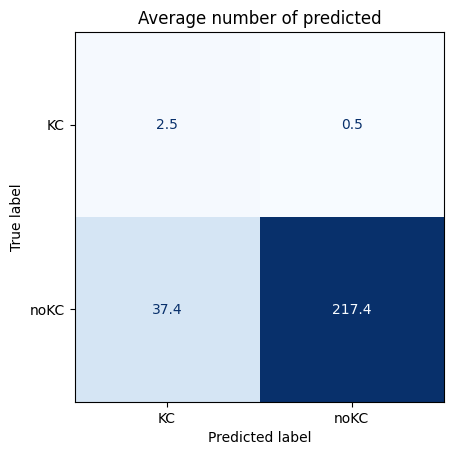

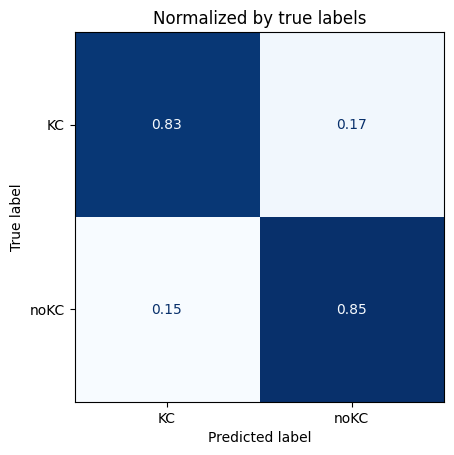

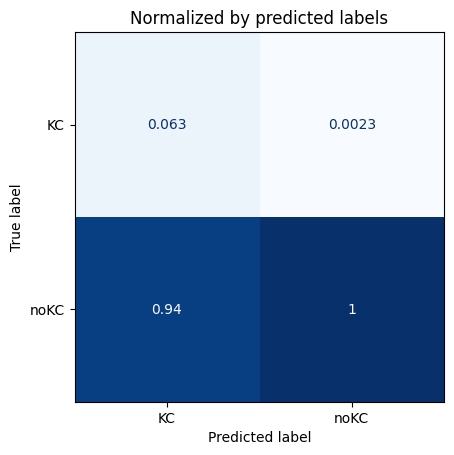

In [151]:
run_best_model(X_overall_scaled2, y_overall, clf=best_model_lsym)

### Stratified kFold

In [19]:
def run_StratifiedKFold(X, y, clf):
    print('--------------------- StratifiedKFold ---------------------')
    kf = StratifiedKFold(n_splits=10)

    accuracy = []
    m = ['precision', 'recall', 'f1-score']
    metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
                'KC': {'precision': [], 'recall': [], 'f1-score': []}}
    TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []

    # Fit the models
    # sample_weight = np.ones(len(X))
    # index_KCs = np.where(y == 'KC')
    # weight = int(len(np.where(y=='noKC')[0])/len(np.where(y=='KC')[0]))//2
    # weight = 1 if weight < 1 else weight
    # sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
    # print('Weight applied:', weight)

    print('PERFORMANCE:')
    for i, (train_index, test_index) in enumerate(kf.split(X, y)):
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]
        # sample_weight_train = sample_weight[X_train.index]

        
        clf.fit(X_train, y_train)
        # clf.fit(X_train, y_train, sample_weight=sample_weight_train)
        y_pred = clf.predict(X_test)


        labels_order = ["noKC", "KC"]
        cm = confusion_matrix(y_test, y_pred, labels=labels_order)
        
        TP_avg.append(int(cm[1, 1]))
        FP_avg.append(int(cm[0, 1]))
        FN_avg.append(int(cm[1, 0]))
        TN_avg.append(int(cm[0, 0]))
        
        report = classification_report(y_test, y_pred, output_dict=True)
        for me in m:
            metrics['KC'][me].append(report['KC'][me])
            metrics['noKC'][me].append(report['noKC'][me])
        accuracy.append(report['accuracy'])
        
        print(f'Iteration {i}')
        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('KC predicted vs KC true')
        # plt.show()

        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('noKC predicted vs noKC true')
        # plt.show()

    print()
    
    for me in m:
        print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
        print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
        print()
    print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

    TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
    cm_num = np.array([[TP, FN],[FP, TN]])
    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()

def run_SVC_StratifiedKFold(X, y):
    clf = svm.SVC(C=0.7112359550561798, kernel='rbf', gamma='scale')
    balanced_bagging_classifier = BalancedBaggingClassifier(clf,
                                                            n_estimators = 5,
                                                            sampling_strategy='auto',  
                                                            replacement=False,  # Whether to sample with or without replacement
                                                            random_state=42)
    run_StratifiedKFold(X, y, balanced_bagging_classifier)

def run_NuSVC_StratifiedKFold(X, y, clf):
    # l = len(df_overall) #number of training samples
    # l_pos = len(df_overall[df_overall['Label'] == 'KC']) #number of KC
    # l_neg = len(df_overall[df_overall['Label'] == 'noKC']) #number of noKC
    # nu_selected_corrected = min(l_pos/l,l_neg/l) #* nu_selected
    # print('Nu corrected', nu_selected_corrected)
    # clf = NuSVC(gamma=0.045,nu=0.002,kernel='rbf')
    # #
    # balanced_bagging_classifier = BalancedBaggingClassifier(clf,
    #                                                         n_estimators = 10,
    #                                                         sampling_strategy='auto',  
    #                                                         replacement=False,  # Whether to sample with or without replacement
    #                                                         random_state=42)
    run_StratifiedKFold(X, y, clf)

--------------------- StratifiedKFold ---------------------
PERFORMANCE:
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9

PRECISION noKC - 0.967 +- 0.005
PRECISION KC - 0.652 +- 0.199

RECALL noKC - 0.993 +- 0.004
RECALL KC - 0.281 +- 0.109

F1-SCORE noKC - 0.98 +- 0.004
F1-SCORE KC - 0.386 +- 0.136

Accuracy: 0.961 +- 0.008


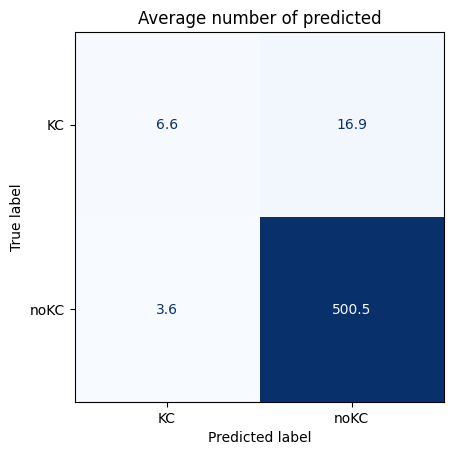

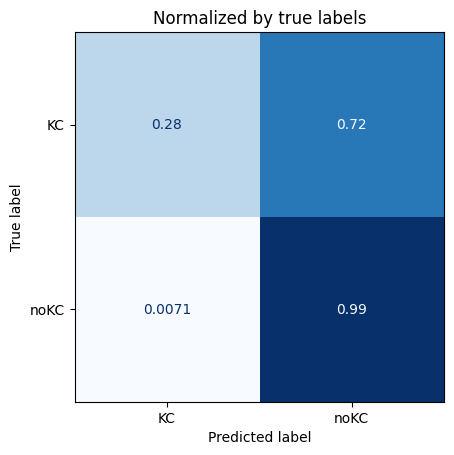

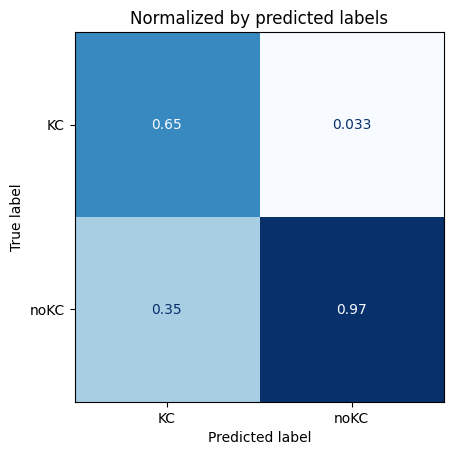

In [ ]:
# run_NuSVC_StratifiedKFold(X_overall_scaled2, y_overall, best_model)

--------------------- StratifiedKFold ---------------------
PERFORMANCE:
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9

PRECISION noKC - 0.998 +- 0.003
PRECISION KC - 0.066 +- 0.024

RECALL noKC - 0.853 +- 0.025
RECALL KC - 0.833 +- 0.224

F1-SCORE noKC - 0.92 +- 0.015
F1-SCORE KC - 0.122 +- 0.043

Accuracy: 0.853 +- 0.026


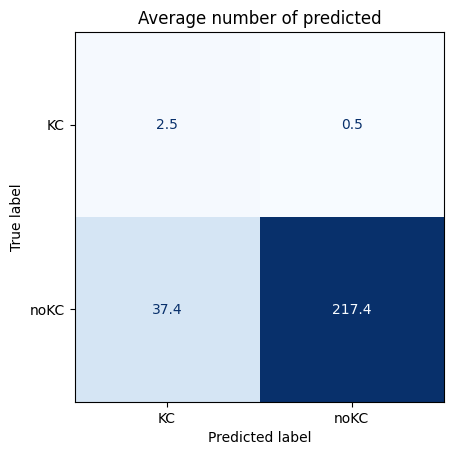

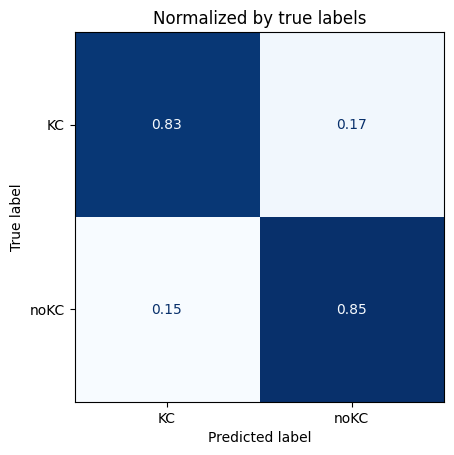

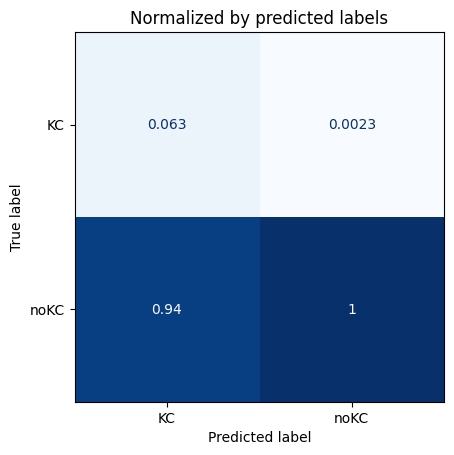

In [152]:
run_NuSVC_StratifiedKFold(X_overall_scaled2, y_overall, best_model_lsym)

### Stratified Shuffle Split

In [22]:
def run_StratifiedShuffleSplit(X, y, clf):
    print('--------------------- StratifiedShuffleSplit ---------------------')
    sh = StratifiedShuffleSplit(n_splits=10, test_size=0.2)

    accuracy = []
    m = ['precision', 'recall', 'f1-score']
    metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
                'KC': {'precision': [], 'recall': [], 'f1-score': []}}
    TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []
    # sample_weight = np.ones(len(X))
    # index_KCs = np.where(y == 'KC')
    # weight = int(len(np.where(y=='noKC')[0])/len(np.where(y=='KC')[0]))//2
    # sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
    # print('Weight applied:', weight)
    
    print('PERFORMANCE:')
    for i, (train_index, test_index) in enumerate(sh.split(X, y)):
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]
        # sample_weight_train = sample_weight[X_train.index]

        clf.fit(X_train, y_train)
        # clf.fit(X_train, y_train, sample_weight=sample_weight_train)
        y_pred = clf.predict(X_test)


        labels_order = ["noKC", "KC"]
        cm = confusion_matrix(y_test, y_pred, labels=labels_order)
        
        TP_avg.append(int(cm[1, 1]))
        FP_avg.append(int(cm[0, 1]))
        FN_avg.append(int(cm[1, 0]))
        TN_avg.append(int(cm[0, 0]))
        
        report = classification_report(y_test, y_pred, output_dict=True)
        for me in m:
            metrics['KC'][me].append(report['KC'][me])
            metrics['noKC'][me].append(report['noKC'][me])
        accuracy.append(report['accuracy'])
        
        # print(f'Iteration {i}')
        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('KC predicted vs KC true')
        # plt.show()

        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('noKC predicted vs noKC true')
        # plt.show()

    print()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
    y_pred = clf.predict(X_test)
    for me in m:
        print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
        print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
        print()
    print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

    TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
    cm_num = np.array([[TP, FN],[FP, TN]])
    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()

def run_SVC_StratifiedShuffleSplit(X, y):
    clf = svm.SVC(C=0.7112359550561798, kernel='rbf', gamma='scale')
    balanced_bagging_classifier = BalancedBaggingClassifier(clf,
                                                            n_estimators = 5,
                                                            sampling_strategy='auto',  
                                                            replacement=False,  # Whether to sample with or without replacement
                                                            random_state=42)
    run_StratifiedShuffleSplit(X, y, balanced_bagging_classifier)

def run_NuSVC_StratifiedShuffleSplit(X, y, clf):
    # l = len(df_overall) #number of training samples
    # l_pos = len(df_overall[df_overall['Label'] == 'KC']) #number of KC
    # l_neg = len(df_overall[df_overall['Label'] == 'noKC']) #number of noKC
    # nu_selected_corrected = min(l_pos/l,l_neg/l) #* nu_selected
    # print('Nu corrected', nu_selected_corrected)
    # clf = svm.NuSVC(gamma=0.04, kernel='poly', nu=0.108)
    # #svm.NuSVC(gamma=0.019, kernel='poly', nu=0.108)
    # #svm.NuSVC(gamma=0.04, kernel='poly', nu=0.108)
    # balanced_bagging_classifier = BalancedBaggingClassifier(clf,
    #                                                         n_estimators = 5,
    #                                                         sampling_strategy='auto',  
    #                                                         replacement=False,  # Whether to sample with or without replacement
    #                                                         random_state=42)
    run_StratifiedShuffleSplit(X, y, clf)

--------------------- StratifiedShuffleSplit ---------------------
PERFORMANCE:

PRECISION noKC - 0.998 +- 0.002
PRECISION KC - 0.062 +- 0.009

RECALL noKC - 0.841 +- 0.021
RECALL KC - 0.883 +- 0.13

F1-SCORE noKC - 0.913 +- 0.012
F1-SCORE KC - 0.116 +- 0.017

Accuracy: 0.841 +- 0.02


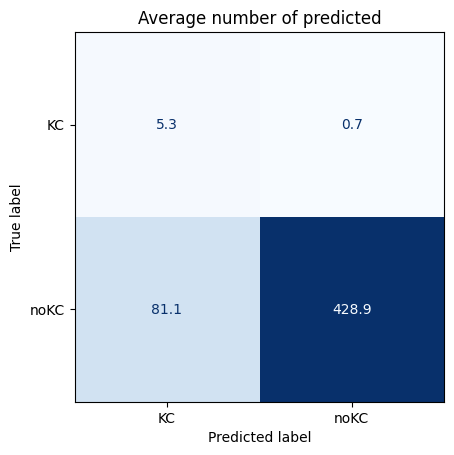

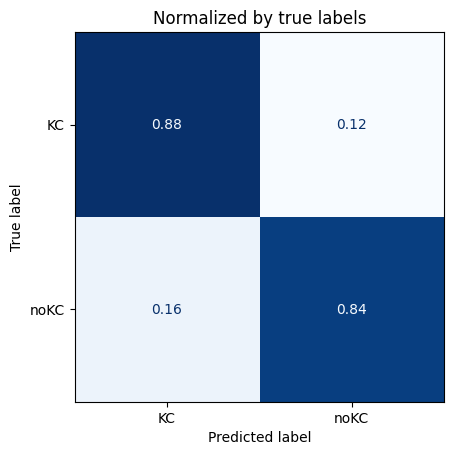

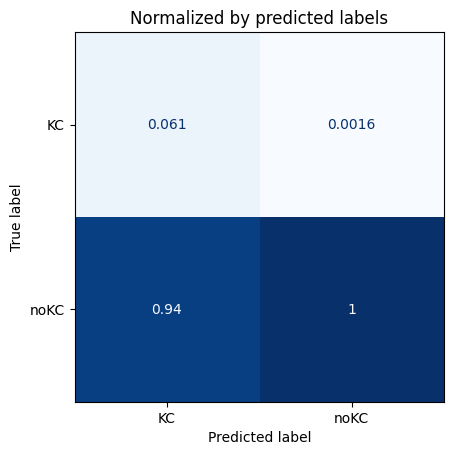

In [153]:
run_NuSVC_StratifiedShuffleSplit(X_overall_scaled2, y_overall, best_model_lsym)

### Group KFold

In [126]:
def run_GroupKFold(X, y, clf, groups):
    print('--------------------- GroupKFold ---------------------')
    gk = GroupKFold(n_splits=5)

    accuracy = []
    m = ['precision', 'recall', 'f1-score']
    metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
                'KC': {'precision': [], 'recall': [], 'f1-score': []}}
    TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []
    # sample_weight = np.ones(len(X))
    # index_KCs = np.where(y == 'KC')
    # weight = int(len(np.where(y=='noKC')[0])/len(np.where(y=='KC')[0]))//2
    # sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
    # print('Weight applied:', weight)
    
    print('PERFORMANCE:')
    for i, (train_index, test_index) in enumerate(gk.split(X, y, groups=groups)):
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]
        # sample_weight_train = sample_weight[X_train.index]

        clf.fit(X_train, y_train)
        # clf.fit(X_train, y_train, sample_weight=sample_weight_train)
        y_pred = clf.predict(X_test)


        labels_order = ["noKC", "KC"]
        cm = confusion_matrix(y_test, y_pred, labels=labels_order)
        
        TP_avg.append(int(cm[1, 1]))
        FP_avg.append(int(cm[0, 1]))
        FN_avg.append(int(cm[1, 0]))
        TN_avg.append(int(cm[0, 0]))
        
        report = classification_report(y_test, y_pred, output_dict=True)
        for me in m:
            metrics['KC'][me].append(report['KC'][me])
            metrics['noKC'][me].append(report['noKC'][me])
        accuracy.append(report['accuracy'])
        
        # print(f'Iteration {i}')
        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('KC predicted vs KC true')
        # plt.show()

        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('noKC predicted vs noKC true')
        # plt.show()

    print()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
    y_pred = clf.predict(X_test)
    for me in m:
        print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
        print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
        print()
    print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

    TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
    cm_num = np.array([[TP, FN],[FP, TN]])
    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()

def run_SVC_GroupKFold(X, y, groups):
    clf = svm.NuSVC(nu=0.06720806496779613, kernel='rbf', gamma='scale')
    balanced_bagging_classifier = BalancedBaggingClassifier(clf,
                                                            n_estimators = 5,
                                                            sampling_strategy='auto',  
                                                            replacement=False,  # Whether to sample with or without replacement
                                                            random_state=42)
    run_GroupKFold(X, y, balanced_bagging_classifier, groups)

def run_NuSVC_GroupKFold(X, y, clf, groups):
    # l = len(df_overall) #number of training samples
    # l_pos = len(df_overall[df_overall['Label'] == 'KC']) #number of KC
    # l_neg = len(df_overall[df_overall['Label'] == 'noKC']) #number of noKC
    # nu_selected_corrected = min(l_pos/l,l_neg/l) #* nu_selected
    # print('Nu corrected', nu_selected_corrected)
    
    # clf = svm.NuSVC(gamma=0.019, kernel='poly', nu=0.108)
    # balanced_bagging_classifier = BalancedBaggingClassifier(clf,
    #                                                         n_estimators = 10,
    #                                                         sampling_strategy='auto',  
    #                                                         replacement=False,  # Whether to sample with or without replacement
    #                                                         random_state=42)
    run_GroupKFold(X, y, clf, groups=groups)

In [154]:
groups = df_overall['Subject'].values
groups

array([1., 1., 1., ..., 5., 5., 5.])

--------------------- GroupKFold ---------------------
PERFORMANCE:

PRECISION noKC - 0.999 +- 0.001
PRECISION KC - 0.068 +- 0.012

RECALL noKC - 0.856 +- 0.041
RECALL KC - 0.942 +- 0.079

F1-SCORE noKC - 0.921 +- 0.024
F1-SCORE KC - 0.127 +- 0.021

Accuracy: 0.857 +- 0.04


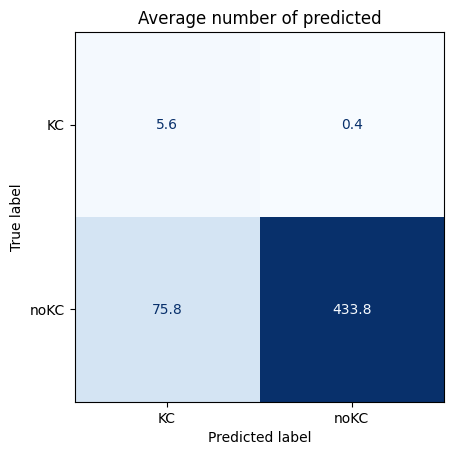

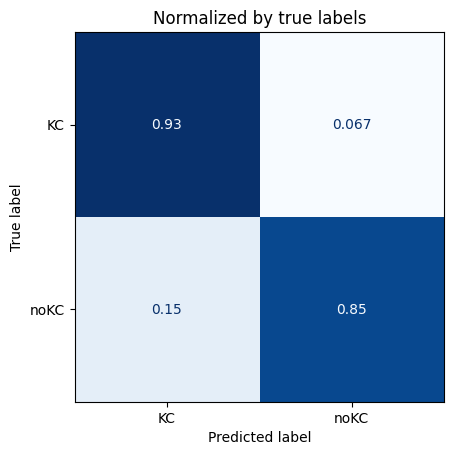

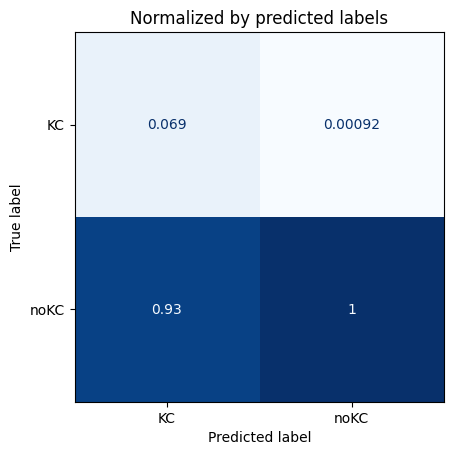

In [155]:
run_NuSVC_GroupKFold(X_overall_scaled2, y_overall, best_model_lsym, groups)

# Characteristics

In [ ]:
cols = ['power_SO', 'power_SO_relative', 
        'power_delta', 'power_delta_relative', 
        'power_sigma', 'power_sigma_relative', 
        'maxi', 'idx_maxi', 
        'mini', 'idx_mini', 
        'slope_positive', 
        'second_maxi', 'idx_second_maxi', 
        'slope_negative', 
        'num_of_zc_min_max', 
        'num_of_zc_max_min', 'kurtosis', 
        'skewness',
        'KC']

df1 = pd.DataFrame(columns=cols)

for event in df_model.values:
    output = event[-2]
    event = np.array(event[:-3], dtype='float')
    data = build_data_features(event, fs)
    data.append(output)
    df1.loc[len(df1)] = pd.Series(data, index=df1.columns)

In [ ]:
scaler = StandardScaler()
X_characteristics = df1.drop(columns=['KC'])
print(scaler.fit(X_characteristics))

In [ ]:
X_characteristics = scaler.transform(X_characteristics)
X_characteristics = pd.DataFrame(data=X_characteristics, columns=df1.columns[:-1])
y_characteristics = df1['KC']

In [ ]:
X_ch_train, X_ch_test, y_ch_train, y_ch_test = train_test_split(X_characteristics, y_characteristics, test_size=0.2, random_state=10)

## SVC

In [ ]:
scores = []
kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
for k in kernels:
    score = svm.SVC(kernel=k).fit(X_ch_train, y_ch_train).score(X_ch_test, y_ch_test)
    scores.append(score)

plt.plot(kernels, scores)
plt.title('SVM type of kernel comparison')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
scores = []
Cs = np.linspace(0.1,0.9,9*10)
for c in Cs:
    score = svm.SVC(C=c, kernel='linear').fit(X_ch_train, y_ch_train).score(X_ch_test, y_ch_test)
    scores.append(score)

plt.plot(Cs, scores)
plt.title('SVM C parameter comparison')
plt.ylabel('Accuracy')
plt.xlabel('C')
plt.show()

In [ ]:
Cs[scores.index(max(scores))]

In [ ]:
scores = []
gammas = ['scale', 'auto']
for g in gammas:
    score = svm.SVC(C=0.22, kernel='linear', gamma=g).fit(X_ch_train, y_ch_train).score(X_ch_test, y_ch_test)
    scores.append(score)

plt.plot(gammas, scores)
plt.title('SVM gamma parameter comparison')
plt.ylabel('Accuracy')
plt.xlabel('gamma')
plt.show()

In [ ]:
clf = svm.SVC(C=0.22, kernel='linear', gamma='auto')
for sc in ('accuracy','f1_macro','recall_macro'):
    print(sc)
    scores = cross_val_score(clf, X_characteristics, y_characteristics, cv=10, scoring=sc)
    print(scores.mean(), '+-', scores.std())

## NU-SVM

In [ ]:
scores = []
nus = np.linspace(0.1,0.9,9*10)
for n in nus:
    score = svm.NuSVC(nu=n, kernel='rbf').fit(X_ch_train, y_ch_train).score(X_ch_test, y_ch_test)
    scores.append(score)

plt.plot(nus, scores)
plt.title('NuSVM Nu parameter comparison')
plt.ylabel('Accuracy')
plt.xlabel('Nu')
plt.show()

In [ ]:
nus[scores.index(max(scores))]

In [ ]:
clf = svm.NuSVC(nu=nus[scores.index(max(scores))], kernel='rbf', gamma='scale')

for sc in ('accuracy','f1_macro','recall_macro'):
    print(sc)
    scores = cross_val_score(clf, X_characteristics, y_characteristics, cv=10, scoring=sc)
    print(scores.mean(), '+-', scores.std())

## Group KFold

In [ ]:
groups = df_model['Subject'].values
gk = GroupKFold(n_splits=5)

accuracy = []
m = ['precision', 'recall', 'f1-score']
metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
            'KC': {'precision': [], 'recall': [], 'f1-score': []}}

for i, (train_index, test_index) in enumerate(gk.split(X_characteristics, y_characteristics, groups=groups)):
    X_train, X_test = X_characteristics.loc[train_index], X_characteristics.loc[test_index]
    y_train, y_test = y_characteristics.loc[train_index], y_characteristics.loc[test_index]

    clf = svm.SVC(C=0.26, kernel='rbf', gamma='scale')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    for me in m:
        metrics['noKC'][me].append(report['KC'][me])
        metrics['KC'][me].append(report['noKC'][me])
    accuracy.append(report['accuracy'])

print()
for me in m:
    print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
    print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
    print()
print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

# Model definition

In [ ]:
df_noKC_to_test = pd.DataFrame(data=[], columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject", "Label"])

for subject in subjects:
    eeg_channel, path_file, scoring_path, _, cut_off_freqs = load_configuration_parameters(subject, subject, mode)
    df_data = pd.read_excel(r"data\annotations\Resume_Annotations_2025.xlsx", sheet_name=subject[3:])[['onset', 'duration','Label','CG','LG']]

    df_noKC = df_data[df_data.Label == 'noKC']

    df_noKC = df_noKC[['onset','duration','Label']]


    #Load file
    raw, channels = load_file(path_file)
    fs = raw.info['sfreq']

    #Filter each channel depending on type
    raw_filtered = filter_raw_depending_on_channel_type(raw, channels, cut_off_freqs)

    #Structure data depending on channel type
    raw_restructured, _ = structure_data_depending_on_channel_type(raw_filtered, channels, eeg_channels_selected=[eeg_channel])

    #Load and set labels (scoring and old annotations)
    raw_with_sleep_stages = set_sleep_stages_labels(raw_restructured, scoring_path)

    # Get eeg signal
    eeg_signal = raw_with_sleep_stages.get_data(picks=[eeg_channel])[0]
    eeg_signal = eeg_signal * 1e6

    #Set annotations
    noKC_annots = mne.Annotations(onset=df_noKC.onset, duration=df_noKC.duration, description=df_noKC.Label)
    raw_with_all_annotations = raw_with_sleep_stages.copy().set_annotations(noKC_annots)

    #List of events
    df_events = pd.DataFrame(data=[], columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject", "Label"])
    for annot in raw_with_all_annotations.annotations:
        noKC = get_noKC_event(annot, eeg_signal, sfreq=fs, window=window)
        df_events.loc[len(df_events)] = [float(i) for i in noKC] + [subject, 'noKC']

    df_noKC_to_test = pd.concat([df_noKC_to_test, df_events],  ignore_index=True)

In [ ]:
df_noKC_to_test

In [ ]:
import joblib

In [ ]:
clf_selected = svm.NuSVC(nu=max_nus, kernel='rbf', gamma='scale')
clf.fit(X, y)

In [ ]:
X_noKC = df_noKC_to_test.drop(columns=['Label','Subject'])

In [ ]:
results = clf.predict(X_noKC)
unique, counts = np.unique(results, return_counts=True)

In [ ]:
print(unique[0], counts[0])
print(unique[1], counts[1])


In [ ]:
X_noKC.iloc[results == 'KC']

In [ ]:
t = np.linspace(0, 2, int(2*fs))
plt.figure(figsize=(15,5))
for x_data in X_noKC.iloc[results == 'KC'].values:
    plt.plot(t, x_data, alpha=0.5)
plt.plot(t,np.mean(X_noKC.iloc[results == 'KC'].values, axis=0), 'black')
plt.ylim(-100, 100)
plt.show()

In [ ]:
path = os.path.join(configuration.REPORTS_ROOT, 'models', f'NuSVM_C{round(max_nus,4)}_rbf_gammaScale_2025-05-04')
joblib.dump(clf, path+'.joblib')